# ✨ Essai Virtuel Cosmétique — PFE
**Plateforme intelligente d'essai virtuel et de recommandation de produits cosmétiques**

Ce notebook permet de :
- 📸 Capturer une photo via la webcam du navigateur
- 💄 Appliquer du maquillage (gloss/rouge à lèvres) avec rendu réaliste
- 🔬 Analyser la teinte de peau (Fitzpatrick + sous-ton)

> **API utilisée :** `mp.tasks.vision.FaceLandmarker` (nouvelle API MediaPipe Tasks, compatible 0.10.14+)

---

## 📦 Cellule 1 — Installation et téléchargement du modèle

In [ ]:
!pip install -q mediapipe opencv-python-headless numpy Pillow

# Télécharger le modèle FaceLandmarker (obligatoire pour la nouvelle API)
!wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

import mediapipe as mp
print(f'✅ MediaPipe {mp.__version__} installé')
print('✅ Modèle face_landmarker.task téléchargé')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.7 MB/s eta 0:00:00
✅ MediaPipe 0.10.33 installé
✅ Modèle face_landmarker.task téléchargé


## 📥 Cellule 2 — Imports

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional
import time
import base64
from IPython.display import display, HTML, clear_output
from google.colab.output import eval_js
import ipywidgets as widgets
from io import BytesIO
from PIL import Image as PILImage

print('✅ Tous les imports OK')

✅ Tous les imports OK


## ⚙️ Cellule 3 — Configuration produits & landmarks

In [ ]:
@dataclass
class MakeupColor:
    """Représente une couleur de produit cosmétique en BGR."""
    name: str
    bgr: Tuple[int, int, int]
    opacity: float = 0.55
    hex_preview: str = ''

PRODUCT_COLORS: Dict[str, MakeupColor] = {
    'rouge':    MakeupColor('Rouge Classique',   (40, 40, 200),   0.55, '#C82828'),
    'rose':     MakeupColor('Rose Pétale',       (147, 130, 210), 0.50, '#D28293'),
    'bordeaux': MakeupColor('Bordeaux Intense',  (30, 20, 130),   0.60, '#821420'),
    'nude':     MakeupColor('Nude Naturel',       (140, 160, 200), 0.40, '#C8A08C'),
    'corail':   MakeupColor('Corail Été',        (100, 120, 220), 0.50, '#DC7864'),
    'berry':    MakeupColor('Berry Profond',     (80, 30, 140),   0.58, '#8C1E50'),
}

# Indices des landmarks pour les lèvres (identiques FaceMesh 478 points)
LIPS_UPPER = [61, 185, 40, 39, 37, 0, 267, 269, 270, 409, 291,
              308, 324, 318, 402, 317, 14, 87, 178, 88, 95, 78, 61]
LIPS_LOWER = [61, 78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
              291, 375, 321, 405, 314, 17, 84, 181, 91, 146, 61]

# Landmarks pour l'échantillonnage de teinte de peau (6 zones)
SKIN_SAMPLE_LANDMARKS = {
    'joue_droite': 234,
    'joue_gauche': 454,
    'front': 10,
    'menton': 152,
    'joue_haute_d': 137,
    'joue_haute_g': 366,
}

# Fitzpatrick thresholds (basés sur L* en LAB)
FITZPATRICK = [
    (80, 'Type I',   'Très claire — brûle toujours, ne bronze jamais'),
    (70, 'Type II',  'Claire — brûle facilement, bronze peu'),
    (60, 'Type III', 'Moyenne — brûle modérément, bronze progressivement'),
    (50, 'Type IV',  'Mate — brûle peu, bronze facilement'),
    (35, 'Type V',   'Foncée — brûle rarement, bronze intensément'),
    (0,  'Type VI',  'Très foncée — ne brûle jamais'),
]

print(f'✅ Configuration chargée — {len(PRODUCT_COLORS)} couleurs disponibles')
for k, c in PRODUCT_COLORS.items():
    print(f'   {k:10s} → {c.name} (opacité {c.opacity})')

✅ Configuration chargée — 6 couleurs disponibles
   rouge      → Rouge Classique (opacité 0.55)
   rose       → Rose Pétale (opacité 0.5)
   bordeaux   → Bordeaux Intense (opacité 0.6)
   nude       → Nude Naturel (opacité 0.4)
   corail     → Corail Été (opacité 0.5)
   berry      → Berry Profond (opacité 0.58)


## 🧠 Cellule 4 — Classe FaceLandmarker (nouvelle API MediaPipe Tasks)

In [ ]:
class FaceLandmarkerWrapper:
    """
    Wrapper autour de la nouvelle API mp.tasks.vision.FaceLandmarker.
    Remplace l'ancienne API mp.solutions.face_mesh qui n'existe plus
    dans mediapipe >= 0.10.14.

    Retourne les landmarks dans le même format que l'ancien API
    (objets avec .x, .y, .z normalisés) pour garder la compatibilité
    avec notre pipeline de rendu.
    """

    def __init__(self, model_path='face_landmarker.task'):
        base_options = mp_python.BaseOptions(
            model_asset_path=model_path
        )
        options = mp_vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=mp_vision.RunningMode.IMAGE,
            num_faces=1,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.landmarker = mp_vision.FaceLandmarker.create_from_options(options)

    def detect(self, frame_bgr):
        """
        Détecte les landmarks faciaux sur une image BGR.

        Args:
            frame_bgr: numpy array BGR (format OpenCV)

        Returns:
            Liste de landmarks (NormalizedLandmark avec .x, .y, .z)
            ou None si aucun visage détecté.
        """
        # Convertir BGR → RGB pour MediaPipe
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        # Créer un objet mp.Image à partir du numpy array
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=frame_rgb
        )

        # Détection
        result = self.landmarker.detect(mp_image)

        if result.face_landmarks and len(result.face_landmarks) > 0:
            return result.face_landmarks[0]  # Premier visage
        return None

    def close(self):
        self.landmarker.close()


# Test rapide
try:
    _test = FaceLandmarkerWrapper()
    _test.close()
    print('✅ FaceLandmarker initialisé avec succès (nouvelle API Tasks)')
except Exception as e:
    print(f'❌ Erreur initialisation : {e}')

✅ FaceLandmarker initialisé avec succès (nouvelle API Tasks)


## 💄 Cellule 5 — Pipeline de rendu maquillage réaliste

In [ ]:
class RealisticMakeupApplicator:
    """
    Applique du maquillage de manière réaliste.
    Pipeline en 5 étapes :
      1. Masque de segmentation (polygone landmarks)
      2. Feathering (GaussianBlur sur les bords)
      3. Couche de couleur
      4. Alpha blending par pixel
      5. Reflet spéculaire (brillance)
    """

    def __init__(self, model_path='face_landmarker.task',
                 feather_radius=7, specular_intensity=0.25):
        self.feather_radius = feather_radius
        self.specular_intensity = specular_intensity
        self.detector = FaceLandmarkerWrapper(model_path)

    def _get_pts(self, landmarks, indices, w, h):
        """Convertit les landmarks normalisés en coordonnées pixel."""
        return np.array(
            [(int(landmarks[i].x * w), int(landmarks[i].y * h))
             for i in indices],
            dtype=np.int32
        )

    def _create_lip_mask(self, landmarks, w, h):
        """Masque des lèvres avec feathering."""
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [self._get_pts(landmarks, LIPS_UPPER, w, h)], 255)
        cv2.fillPoly(mask, [self._get_pts(landmarks, LIPS_LOWER, w, h)], 255)
        ks = self.feather_radius * 2 + 1
        return cv2.GaussianBlur(mask, (ks, ks), 0).astype(np.float32) / 255.0

    def _create_specular(self, landmarks, w, h, lip_mask):
        """Reflet spéculaire au centre des lèvres."""
        cb = landmarks[17]  # bas centre lèvre
        ct = landmarks[0]   # haut centre lèvre
        cx = int(((cb.x + ct.x) / 2) * w)
        cy = int((cb.y * 0.65 + ct.y * 0.35) * h)
        lw = int(abs(landmarks[291].x - landmarks[61].x) * w)
        lh = int(abs(cb.y - ct.y) * h)
        spec = np.zeros((h, w), dtype=np.float32)
        if lw > 0 and lh > 0:
            cv2.ellipse(spec, (cx, cy), (lw // 3, max(lh // 4, 1)),
                        0, 0, 360, 1.0, -1)
            spec = cv2.GaussianBlur(spec, (31, 31), 0) * lip_mask
        return spec

    def apply_lip_color(self, frame, landmarks, color):
        """Applique la couleur sur les lèvres avec le pipeline complet."""
        h, w = frame.shape[:2]

        # Étape 1+2 : Masque segmenté + feathering
        lip_mask = self._create_lip_mask(landmarks, w, h)

        # Étape 3 : Couche couleur
        color_layer = np.full_like(frame, color.bgr, dtype=np.uint8)

        # Étape 4 : Alpha blending par pixel
        alpha = np.stack([lip_mask * color.opacity] * 3, axis=-1)
        result = (frame.astype(np.float32) * (1 - alpha)
                  + color_layer.astype(np.float32) * alpha)

        # Étape 5 : Reflet spéculaire
        specular = self._create_specular(landmarks, w, h, lip_mask)
        result += np.stack([specular] * 3, axis=-1) * 255.0 * self.specular_intensity

        return np.clip(result, 0, 255).astype(np.uint8)

    def process_frame(self, frame, color_key='rouge'):
        """
        Traite une frame complète : détection + maquillage.
        Returns: (frame_résultat, métadonnées)
        """
        t0 = time.perf_counter()
        color = PRODUCT_COLORS.get(color_key, PRODUCT_COLORS['rouge'])
        meta = {'face_detected': False, 'latency_ms': 0}

        landmarks = self.detector.detect(frame)

        if landmarks is not None:
            meta['face_detected'] = True
            frame = self.apply_lip_color(frame, landmarks, color)

        meta['latency_ms'] = round((time.perf_counter() - t0) * 1000, 2)
        return frame, meta

    def close(self):
        self.detector.close()


print('✅ RealisticMakeupApplicator prêt (pipeline 5 étapes)')

✅ RealisticMakeupApplicator prêt (pipeline 5 étapes)


## 🔬 Cellule 6 — Analyseur de teinte de peau

In [ ]:
class SkinToneAnalyzer:
    """
    Analyse la teinte de peau avec échantillonnage multi-points.
    - 6 landmarks (joues, front, menton)
    - Médiane LAB (robuste aux outliers)
    - Classification Fitzpatrick I-VI
    - Détection du sous-ton (chaud/froid/neutre)
    """

    def __init__(self, model_path='face_landmarker.task', sample_radius=5):
        self.r = sample_radius
        self.detector = FaceLandmarkerWrapper(model_path)

    def analyze(self, frame_bgr):
        """Analyse complète de la teinte de peau."""
        h, w = frame_bgr.shape[:2]

        landmarks = self.detector.detect(frame_bgr)
        if landmarks is None:
            return {'error': 'Aucun visage détecté'}

        lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)

        # Échantillonner chaque zone
        samples = []
        for zone, idx in SKIN_SAMPLE_LANDMARKS.items():
            lm = landmarks[idx]
            px, py = int(lm.x * w), int(lm.y * h)
            y1 = max(0, py - self.r)
            y2 = min(h, py + self.r + 1)
            x1 = max(0, px - self.r)
            x2 = min(w, px + self.r + 1)
            if y2 > y1 and x2 > x1:
                samples.append(lab[y1:y2, x1:x2].reshape(-1, 3))

        if not samples:
            return {'error': 'Échantillonnage échoué'}

        # Médiane sur tous les pixels échantillonnés
        all_pixels = np.concatenate(samples, axis=0)
        med = np.median(all_pixels, axis=0)
        L, a, b = float(med[0]), float(med[1]), float(med[2])

        # Classification Fitzpatrick
        ftype, fdesc = 'N/A', 'N/A'
        for thr, ft, fd in FITZPATRICK:
            if L >= thr:
                ftype, fdesc = ft, fd
                break

        # Sous-ton
        if a > 135 and b > 135:
            undertone = 'Chaud'
        elif a < 125 and b < 125:
            undertone = 'Froid'
        else:
            undertone = 'Neutre'

        return {
            'type': ftype,
            'desc': fdesc,
            'undertone': undertone,
            'L': round(L, 1),
            'a': round(a, 1),
            'b': round(b, 1),
            'samples_used': len(SKIN_SAMPLE_LANDMARKS),
            'landmarks': landmarks,  # pour annotation
        }

    def close(self):
        self.detector.close()


print('✅ SkinToneAnalyzer prêt (6 points, médiane LAB, Fitzpatrick)')

✅ SkinToneAnalyzer prêt (6 points, médiane LAB, Fitzpatrick)


## 📷 Cellule 7 — Fonctions Colab (webcam + affichage)

In [ ]:
def capture_photo(quality=0.8):
    """
    Capture une photo via la webcam du navigateur (JavaScript).
    Fonctionne uniquement dans Google Colab.
    """
    js = '''
    async function cap() {
        const v = document.createElement('video');
        v.setAttribute('playsinline', '');
        const s = await navigator.mediaDevices.getUserMedia(
            {video: {width: 640, height: 480, facingMode: 'user'}});
        v.srcObject = s;
        await v.play();
        await new Promise(r => setTimeout(r, 1000));
        const c = document.createElement('canvas');
        c.width = v.videoWidth; c.height = v.videoHeight;
        const ctx = c.getContext('2d');
        ctx.translate(c.width, 0); ctx.scale(-1, 1);
        ctx.drawImage(v, 0, 0);
        s.getTracks().forEach(t => t.stop());
        return c.toDataURL('image/jpeg', ''' + str(quality) + ''');
    }
    cap();
    '''
    try:
        data_url = eval_js(js)
        _, b64 = data_url.split(',', 1)
        arr = np.frombuffer(base64.b64decode(b64), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_COLOR)
    except Exception as e:
        print(f'❌ Erreur webcam : {e}')
        return None


def show_img(img_bgr, width=600):
    """Affiche une image BGR dans Colab."""
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    buf = BytesIO()
    PILImage.fromarray(rgb).save(buf, format='JPEG', quality=90)
    b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    display(HTML(f'<img src="data:image/jpeg;base64,{b64}" width="{width}"/>'))


def show_comparison(orig, processed, width=700):
    """Affiche original vs résultat côte à côte."""
    h, w0 = orig.shape[:2]
    tw = width // 2
    s = tw / w0
    nh = int(h * s)
    o = cv2.resize(orig, (tw, nh))
    p = cv2.resize(processed, (tw, nh))
    cv2.putText(o, 'Original', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(p, 'Maquillage', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    show_img(np.hstack([o, p]), width)


print('✅ Fonctions Colab prêtes (webcam JS + affichage inline)')

✅ Fonctions Colab prêtes (webcam JS + affichage inline)


---
## 🚀 Cellule 8 — Capturer une photo
**Option A : Webcam** (exécutez cette cellule)

📷 Ouverture de la caméra... (autorisez l'accès si demandé)
✅ Photo capturée ! (640x480)



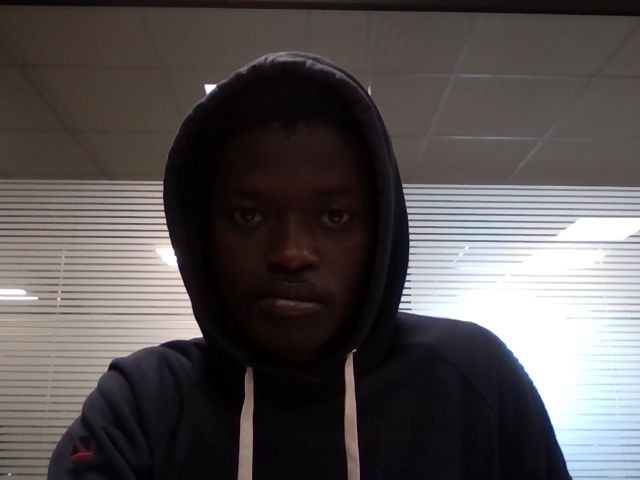

In [ ]:
# ═══════════════════════════════════════
# 📸 CAPTURE PHOTO DEPUIS LA WEBCAM
# ═══════════════════════════════════════

print('📷 Ouverture de la caméra... (autorisez l\'accès si demandé)')
photo = capture_photo()

if photo is not None:
    print(f'✅ Photo capturée ! ({photo.shape[1]}x{photo.shape[0]})')
    show_img(photo, 500)
else:
    print('❌ Échec webcam. Utilisez l\'Option B (upload) dans la cellule suivante.')

**Option B : Upload** — si la webcam ne fonctionne pas

Saving 13622505-19992024.jpg to 13622505-19992024.jpg
✅ 13622505-19992024.jpg chargé (1600x1600)



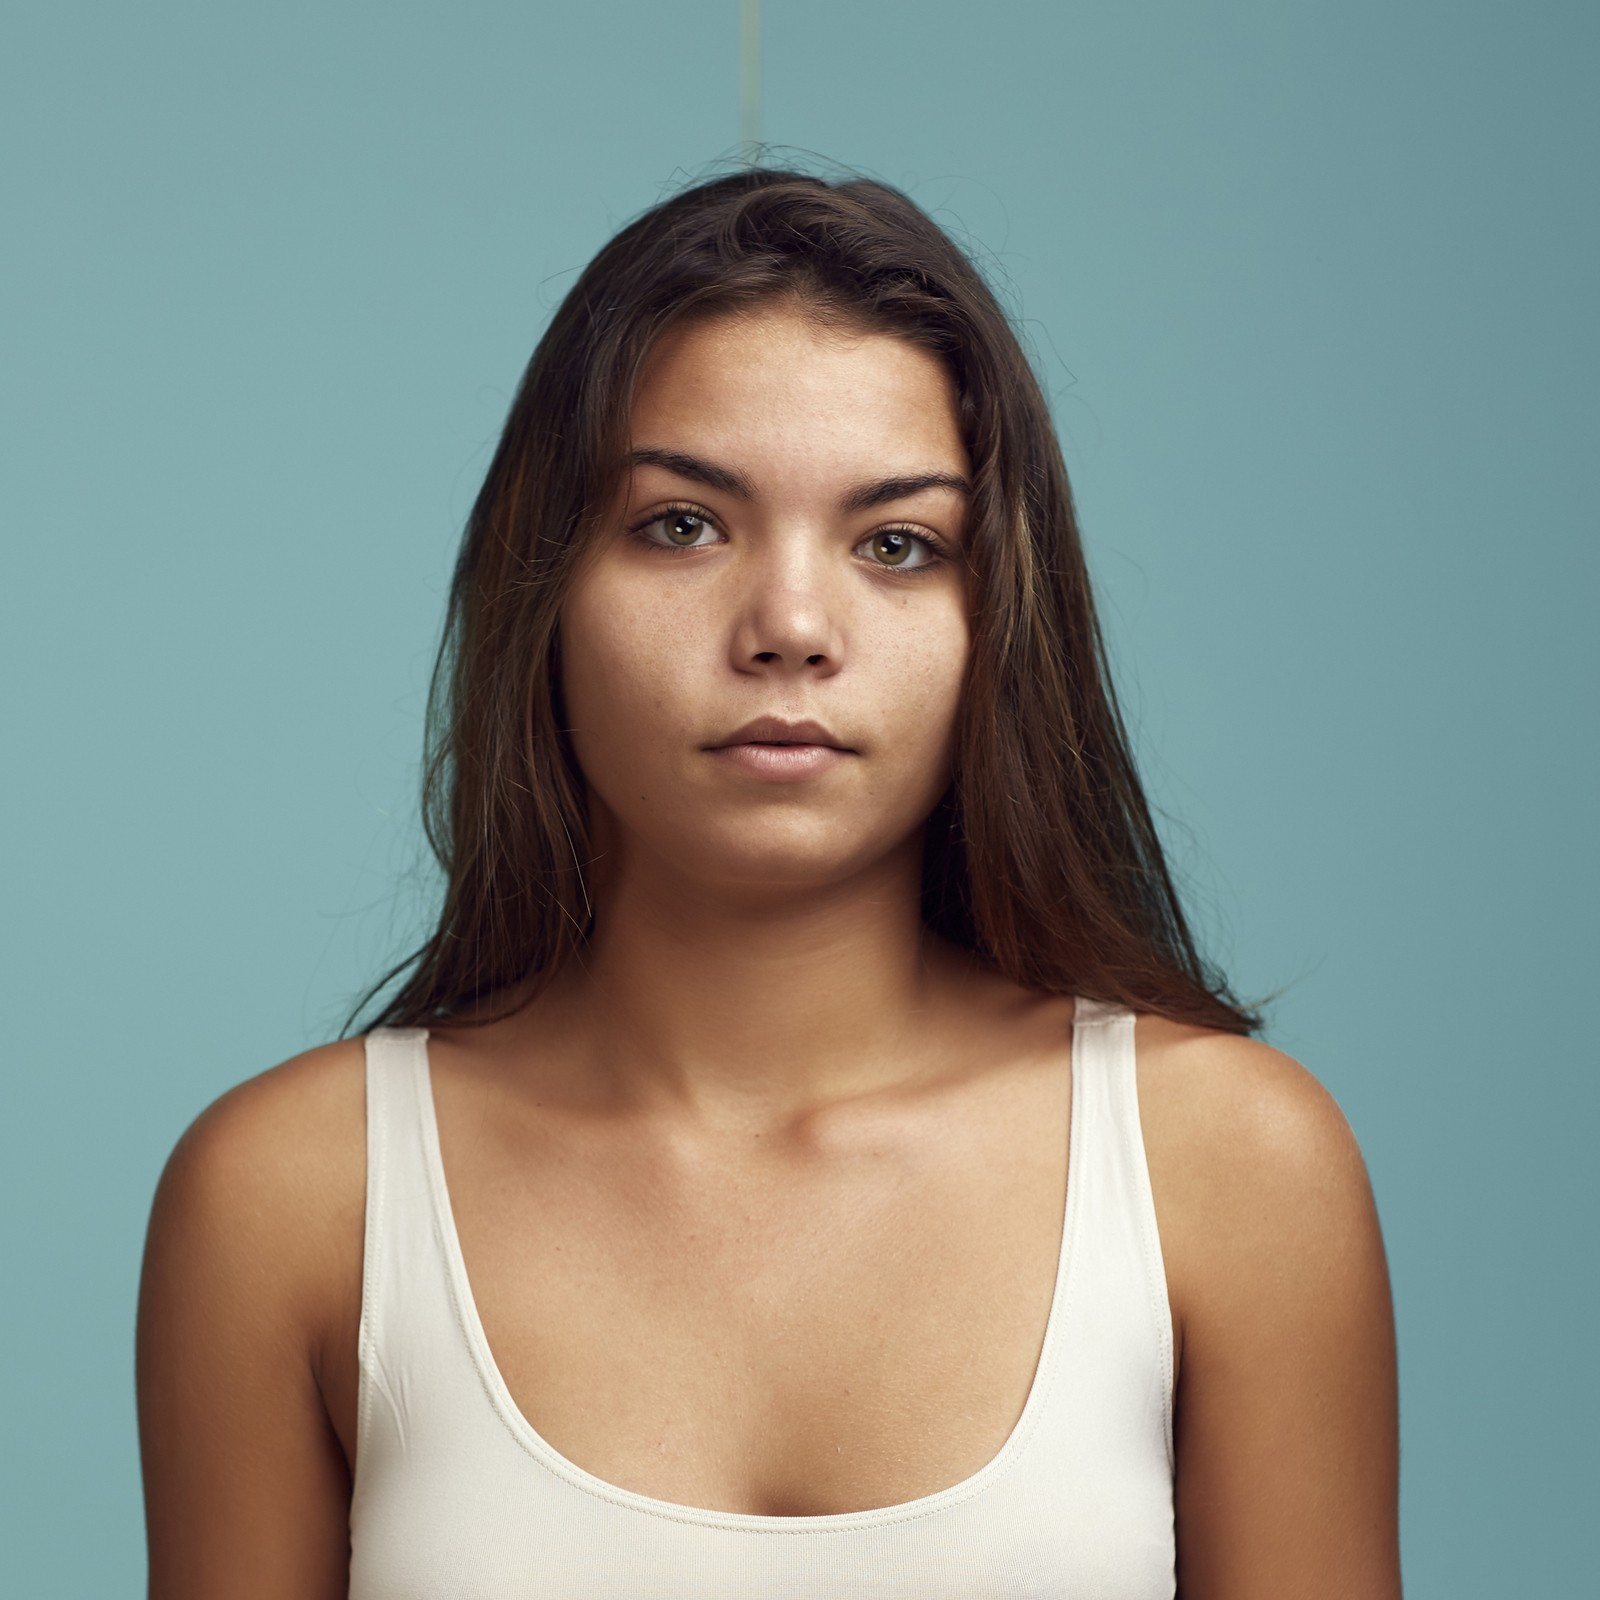

In [ ]:
# ═══════════════════════════════════════
# 📤 UPLOAD D'UNE PHOTO (alternative)
# ═══════════════════════════════════════
# Décommentez les lignes ci-dessous et exécutez :

from google.colab import files
uploaded = files.upload()
for fname, content in uploaded.items():
    arr = np.frombuffer(content, dtype=np.uint8)
    photo = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    print(f'✅ {fname} chargé ({photo.shape[1]}x{photo.shape[0]})')
    show_img(photo, 500)

## 💄 Cellule 9 — Appliquer le maquillage

✅ Rouge Classique appliqué ! (Latence : 219.92ms)



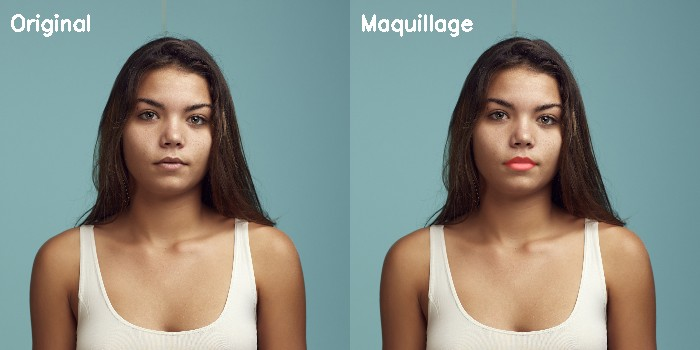

In [ ]:
# ═══════════════════════════════════════
# 💄 APPLICATION DU MAQUILLAGE
# ═══════════════════════════════════════
# Changez la couleur ici :
#   rouge, rose, bordeaux, nude, corail, berry

COULEUR_CHOISIE = 'rouge'  # ← Modifiez ici

if photo is not None:
    applicator = RealisticMakeupApplicator(
        model_path='face_landmarker.task',
        feather_radius=7,
        specular_intensity=0.25
    )

    result, meta = applicator.process_frame(photo.copy(), COULEUR_CHOISIE)
    nom = PRODUCT_COLORS[COULEUR_CHOISIE].name

    if meta['face_detected']:
        print(f'✅ {nom} appliqué ! (Latence : {meta["latency_ms"]}ms)')
        show_comparison(photo, result, 700)
    else:
        print('❌ Aucun visage détecté. Essayez avec un meilleur éclairage.')

    applicator.close()
else:
    print('⚠️ Aucune photo. Exécutez d\'abord la Cellule 8.')

## 🎨 Cellule 10 — Galerie complète (toutes les couleurs)

🎨 Application de toutes les couleurs...

💄 Rouge Classique — 144.96ms



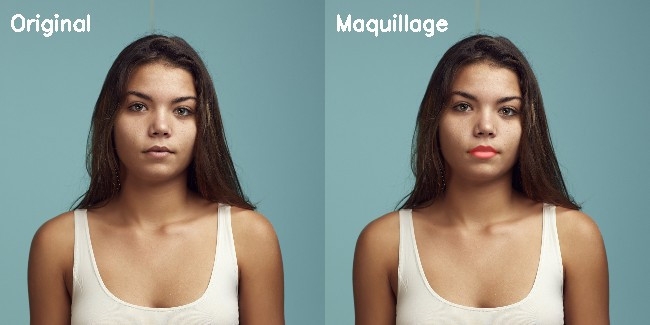


💄 Rose Pétale — 154.95ms



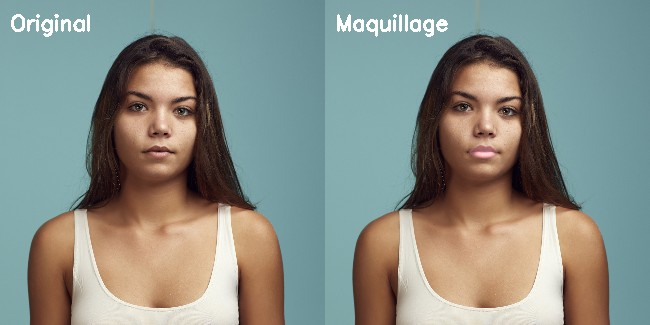


💄 Bordeaux Intense — 159.32ms



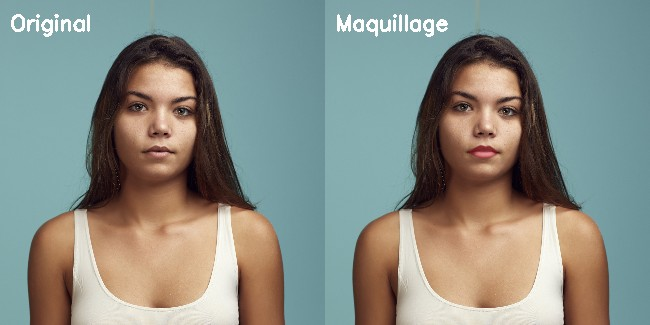


💄 Nude Naturel — 161.67ms



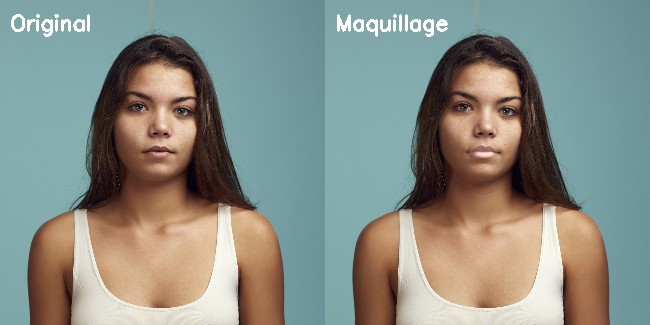


💄 Corail Été — 178.22ms



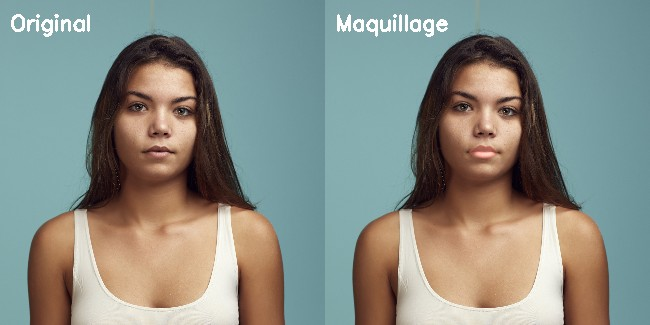


💄 Berry Profond — 166.53ms



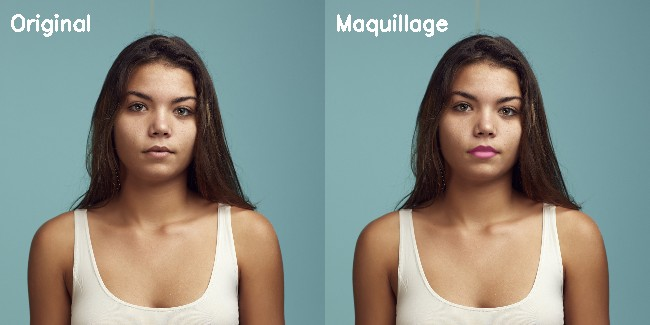

In [ ]:
# ═══════════════════════════════════════
# 🎨 GALERIE — Toutes les teintes
# ═══════════════════════════════════════

if photo is not None:
    applicator = RealisticMakeupApplicator(
        model_path='face_landmarker.task',
        feather_radius=7,
        specular_intensity=0.25
    )
    print('🎨 Application de toutes les couleurs...\n')

    for key, color in PRODUCT_COLORS.items():
        result, meta = applicator.process_frame(photo.copy(), key)
        if meta['face_detected']:
            print(f'💄 {color.name} — {meta["latency_ms"]}ms')
            show_comparison(photo, result, 650)
            print()
        else:
            print(f'❌ {color.name} — visage non détecté')

    applicator.close()
else:
    print('⚠️ Aucune photo. Exécutez d\'abord la Cellule 8.')

## 🔬 Cellule 11 — Analyse de teinte de peau

Classification,Type V
Description,"Foncée — brûle rarement, bronze intensément"
Sous-ton,Chaud
Valeurs LAB,L*=45.0 a*=138.0 b*=138.0
Points échantillonnés,6 zones faciales (médiane)



📍 Points d'échantillonnage visualisés :



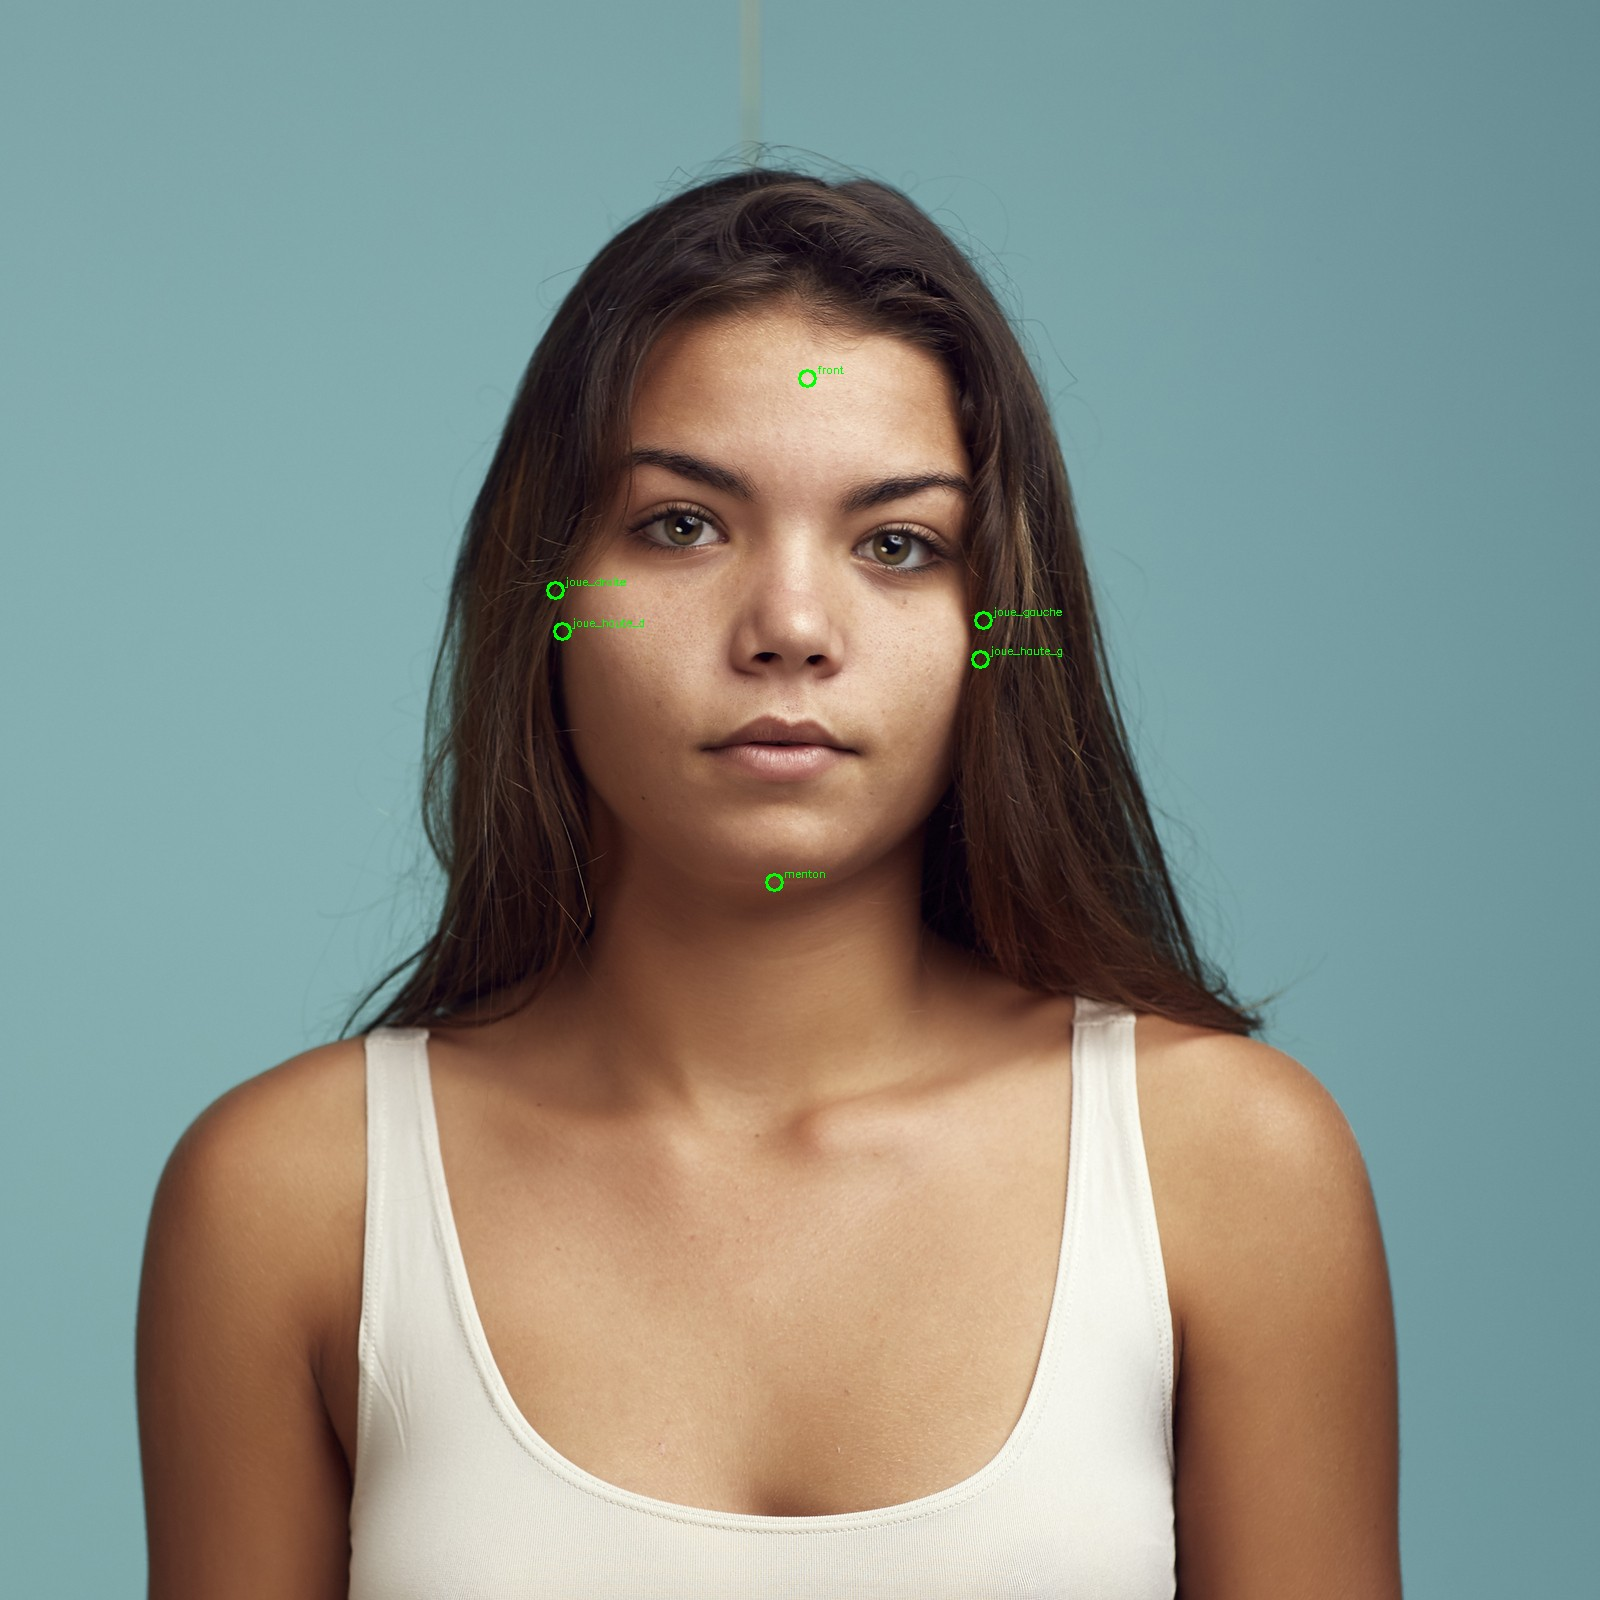

In [ ]:
# ═══════════════════════════════════════
# 🔬 ANALYSE DE TEINTE DE PEAU
# ═══════════════════════════════════════

if photo is not None:
    analyzer = SkinToneAnalyzer(
        model_path='face_landmarker.task',
        sample_radius=5
    )
    info = analyzer.analyze(photo)

    if 'error' not in info:
        # Tableau HTML stylisé
        display(HTML(f'''
        <div style="background: linear-gradient(135deg, #1A0A14, #2a1020);
                    padding: 20px; border-radius: 12px; max-width: 520px;
                    color: white; font-family: Arial; margin: 10px 0;">
            <h3 style="color: #C8956B; margin-top: 0;">🔬 Analyse de teinte de peau</h3>
            <table style="width: 100%; border-collapse: collapse;">
                <tr style="border-bottom: 1px solid #6D2E46;">
                    <td style="padding: 10px; color: #C8956B;"><b>Classification</b></td>
                    <td style="padding: 10px; font-size: 18px;"><b>{info["type"]}</b></td>
                </tr>
                <tr style="border-bottom: 1px solid #6D2E46;">
                    <td style="padding: 10px; color: #C8956B;"><b>Description</b></td>
                    <td style="padding: 10px;">{info["desc"]}</td>
                </tr>
                <tr style="border-bottom: 1px solid #6D2E46;">
                    <td style="padding: 10px; color: #C8956B;"><b>Sous-ton</b></td>
                    <td style="padding: 10px; font-size: 16px;">{info["undertone"]}</td>
                </tr>
                <tr style="border-bottom: 1px solid #6D2E46;">
                    <td style="padding: 10px; color: #C8956B;"><b>Valeurs LAB</b></td>
                    <td style="padding: 10px;">L*={info["L"]}  a*={info["a"]}  b*={info["b"]}</td>
                </tr>
                <tr>
                    <td style="padding: 10px; color: #C8956B;"><b>Points échantillonnés</b></td>
                    <td style="padding: 10px;">{info["samples_used"]} zones faciales (médiane)</td>
                </tr>
            </table>
        </div>
        '''))

        # Annoter la photo avec les 6 points d'échantillonnage
        annotated = photo.copy()
        h, w = annotated.shape[:2]
        lms = info['landmarks']
        for zone, idx in SKIN_SAMPLE_LANDMARKS.items():
            px = int(lms[idx].x * w)
            py = int(lms[idx].y * h)
            cv2.circle(annotated, (px, py), 8, (0, 255, 0), 2)
            cv2.putText(annotated, zone, (px + 10, py - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 255, 0), 1)
        print('\n📍 Points d\'échantillonnage visualisés :')
        show_img(annotated, 450)
    else:
        print(f'❌ {info["error"]}')

    analyzer.close()
else:
    print('⚠️ Aucune photo. Exécutez d\'abord la Cellule 8.')

---
### 📊 Résumé technique
| Composant | Détail |
|-----------|--------|
| API | `mp.tasks.vision.FaceLandmarker` (nouvelle API Tasks) |
| Modèle | `face_landmarker.task` (float16, ~4MB) |
| Landmarks | 478 points 3D normalisés |
| Segmentation | Polygone landmarks + feathering (GaussianBlur) |
| Rendu | Alpha blending par pixel + reflet spéculaire |
| Analyse teinte | 6 landmarks, médiane LAB, Fitzpatrick I-VI |
| Sous-ton | Chaud / Froid / Neutre via canaux a* et b* |
| Compatible | MediaPipe 0.10.14 → 0.10.33+ |